<a href="https://colab.research.google.com/github/Saiful-2/forest-cover-classification/blob/main/notebooks/3_forest_statistical__analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==============================
# 1. Import Libraries
# ==============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import shapiro, f_oneway, chi2_contingency, pearsonr
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression

In [2]:
# ==============================
# 2. Load Dataset
# ==============================
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/forest_cleaned_dataset.csv"
df = pd.read_csv(url)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (47686, 56)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type,Soil_Sum
0,3351,206,27,726,124,3813,192,252,180,2271,...,0,0,0,0,0,1,0,0,1,1
1,2732,129,7,212,1,1082,231,236,137,912,...,0,0,0,0,0,0,0,0,2,1
2,2572,24,9,201,25,957,216,222,142,2191,...,0,0,0,0,0,0,0,0,2,1
3,2824,69,13,417,39,3223,233,214,110,6478,...,0,0,0,0,0,0,0,0,2,1
4,2529,84,5,120,9,1092,227,231,139,4983,...,0,0,0,0,0,0,0,0,2,1


In [3]:
# ==============================
# 3. Basic Info
# ==============================
df.info()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47686 entries, 0 to 47685
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Elevation                           47686 non-null  int64
 1   Aspect                              47686 non-null  int64
 2   Slope                               47686 non-null  int64
 3   Horizontal_Distance_To_Hydrology    47686 non-null  int64
 4   Vertical_Distance_To_Hydrology      47686 non-null  int64
 5   Horizontal_Distance_To_Roadways     47686 non-null  int64
 6   Hillshade_9am                       47686 non-null  int64
 7   Hillshade_Noon                      47686 non-null  int64
 8   Hillshade_3pm                       47686 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  47686 non-null  int64
 10  Wilderness_Area1                    47686 non-null  int64
 11  Wilderness_Area2                    47686 non-null  int64
 12  Wild

,0
Elevation,0
Aspect,0
Slope,0
Horizontal_Distance_To_Hydrology,0
Vertical_Distance_To_Hydrology,0
Horizontal_Distance_To_Roadways,0
Hillshade_9am,0
Hillshade_Noon,0
Hillshade_3pm,0
Horizontal_Distance_To_Fire_Points,0


In [4]:
# ==============================
# 4. Descriptive Statistics
# ==============================
desc = df.describe()
skew = df.skew()
kurt = df.kurtosis()

print(desc)
print("\nSkewness:\n", skew)
print("\nKurtosis:\n", kurt)

          Elevation        Aspect         Slope  \
count  47686.000000  47686.000000  47686.000000   
mean    2984.518370    154.725160     13.353605   
std      245.772573    111.531535      6.556026   
min     2280.000000      0.000000      0.000000   
25%     2837.000000     58.000000      8.000000   
50%     3007.000000    126.000000     13.000000   
75%     3169.000000    258.000000     18.000000   
max     3694.000000    360.000000     31.000000   

       Horizontal_Distance_To_Hydrology  Vertical_Distance_To_Hydrology  \
count                      47686.000000                    47686.000000   
mean                         273.271715                       44.904983   
std                          213.093318                       56.744079   
min                            0.000000                     -173.000000   
25%                          108.000000                        7.000000   
50%                          228.000000                       29.000000   
75%            

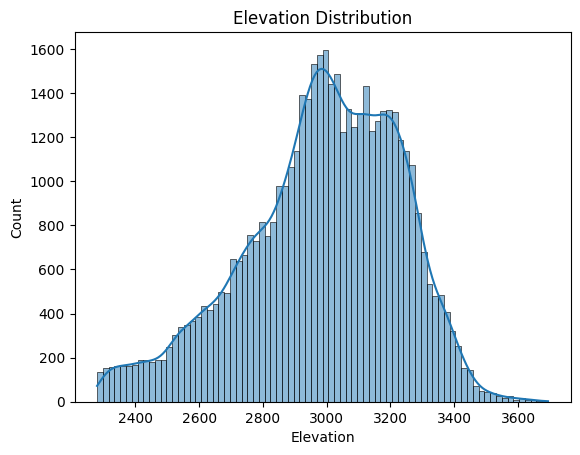

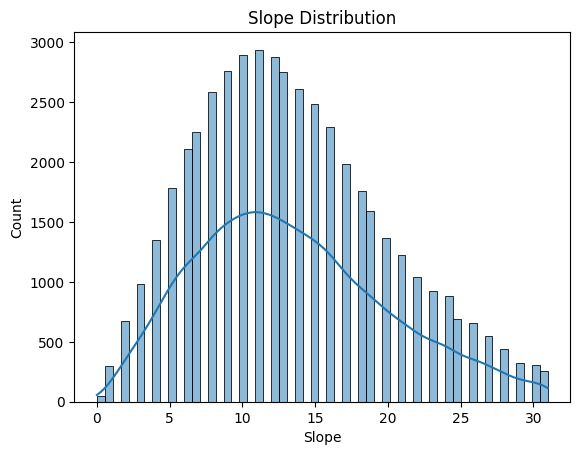

In [5]:
# ==============================
# 5. Distribution Analysis
# ==============================
plt.figure()
sns.histplot(df['Elevation'], kde=True)
plt.title("Elevation Distribution")
plt.show()

plt.figure()
sns.histplot(df['Slope'], kde=True)
plt.title("Slope Distribution")
plt.show()

In [6]:
# ==============================
# 6. Hypothesis Testing Framework
# ==============================
alpha = 0.05


In [7]:
# ==============================
# 7. Normality Test (Shapiro)
# ==============================
sample = df['Elevation'].sample(5000, random_state=42)
stat, p = shapiro(sample)

print("Normality Test p-value:", p)
if p > alpha:
    print("Fail to reject H0 → Data is normal")
else:
    print("Reject H0 → Data is NOT normal")

Normality Test p-value: 7.495171335301699e-27
Reject H0 → Data is NOT normal


In [8]:
# ==============================
# 8. ANOVA Test
# ==============================
groups = [df[df['Cover_Type']==i]['Elevation'] for i in range(1,8)]
stat, p = f_oneway(*groups)

print("ANOVA p-value:", p)
if p < alpha:
    print("Reject H0 → Significant difference exists")
else:
    print("Fail to reject H0")

ANOVA p-value: 0.0
Reject H0 → Significant difference exists


In [9]:
# ==============================
# 9. Regression Analysis (Sklearn)
# ==============================
X = df[['Slope', 'Horizontal_Distance_To_Roadways']]
y = df['Elevation']

lr_model = LinearRegression()
lr_model.fit(X, y)

print("Coefficients:", lr_model.coef_)
print("Intercept:", lr_model.intercept_)

Coefficients: [-2.9639769   0.04725704]
Intercept: 2910.4426684897917


In [10]:
# ==============================
# 10. Regression (Statsmodels - Hypothesis)
# ==============================
X_sm = sm.add_constant(X)
model = sm.OLS(y, X_sm).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              Elevation   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     2761.
Date:                Thu, 16 Apr 2026   Prob (F-statistic):               0.00
Time:                        05:58:08   Log-Likelihood:            -3.2753e+05
No. Observations:               47686   AIC:                         6.551e+05
Df Residuals:                   47683   BIC:                         6.551e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [11]:
# ==============================
# 11. Chi-Square Test
# ==============================
contingency = pd.crosstab(df['Soil_Type1'], df['Cover_Type'])
stat, p, dof, expected = chi2_contingency(contingency)

print("Chi-Square p-value:", p)
if p < alpha:
    print("Reject H0 → Variables are dependent")
else:
    print("Fail to reject H0 → Variables are independent")


Chi-Square p-value: 8.137279704184906e-238
Reject H0 → Variables are dependent


In [12]:
# ==============================
# 12. Correlation Significance Test
# ==============================
corr, p = pearsonr(df['Elevation'], df['Slope'])

print("Correlation:", corr)
print("p-value:", p)

if p < alpha:
    print("Reject H0 → Significant correlation")
else:
    print("No significant correlation")

Correlation: -0.13089398010149753
p-value: 3.1824733901430464e-181
Reject H0 → Significant correlation


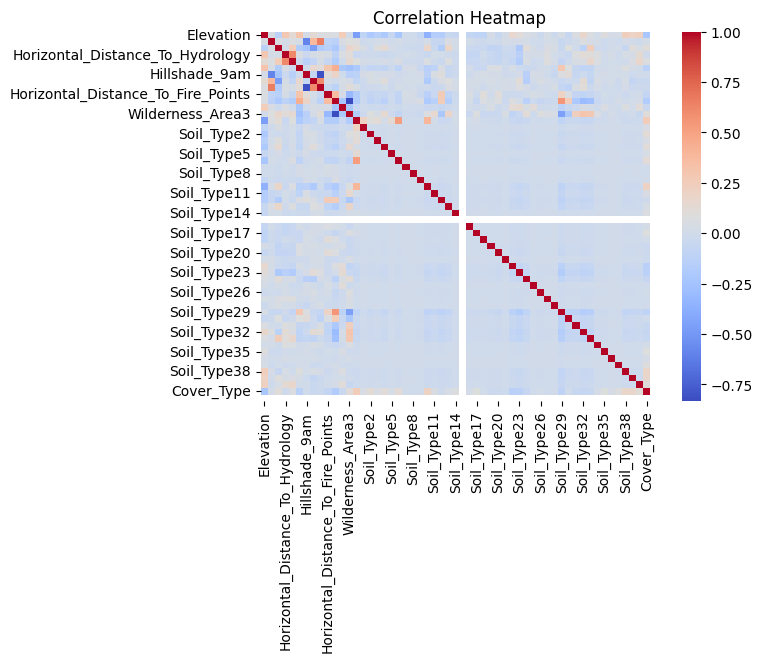

In [13]:
# ==============================
# 13. Visualizations
# ==============================

# Heatmap
plt.figure()
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

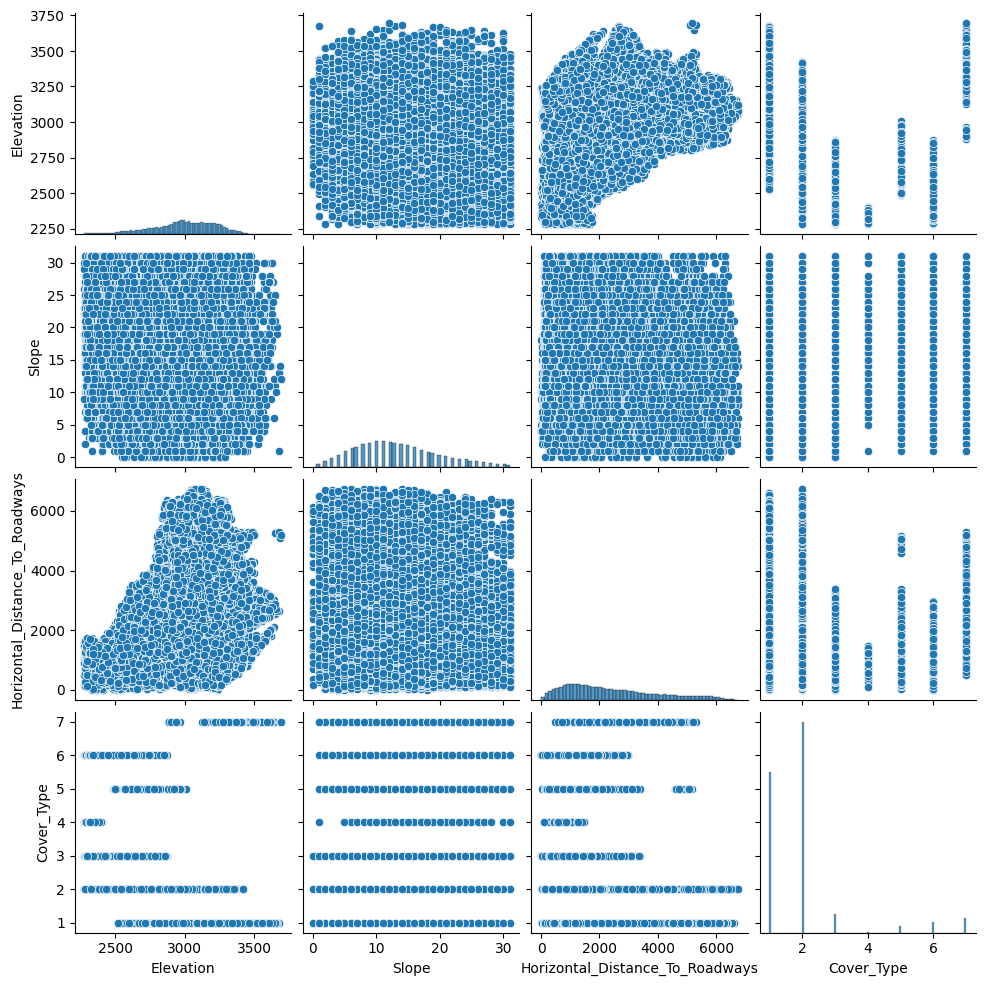

In [15]:
# Pairplot
sns.pairplot(df[['Elevation','Slope','Horizontal_Distance_To_Roadways','Cover_Type']])


In [17]:
# 14. Advanced Analysis
# ==============================

# Outlier Detection
Q1 = df['Elevation'].quantile(0.25)
Q3 = df['Elevation'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['Elevation'] < Q1 - 1.5*IQR) |
              (df['Elevation'] > Q3 + 1.5*IQR)]

print("Number of outliers:", len(outliers))

Number of outliers: 491


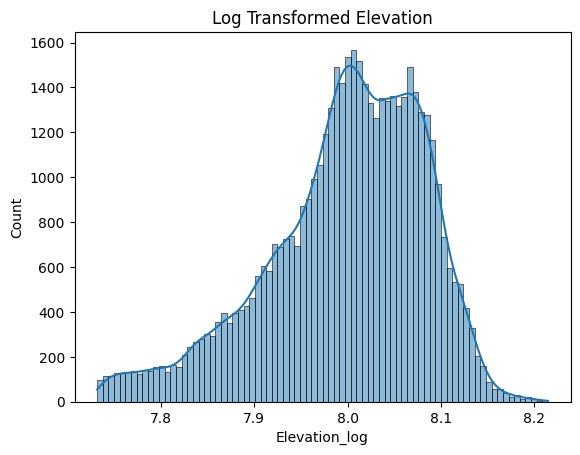

In [18]:
# Log Transformation
df['Elevation_log'] = np.log(df['Elevation'])

plt.figure()
sns.histplot(df['Elevation_log'], kde=True)
plt.title("Log Transformed Elevation")
plt.show()

In [19]:
# ==============================
# 15. Final Insights (Write Manually)
# ==============================
print("""
Key Insights:
1. Elevation differs significantly across forest cover types.
2. Data is not perfectly normally distributed.
3. Moderate correlation exists between elevation and slope.
4. Soil type has dependency with forest cover.
5. Regression shows slope and distance influence elevation.
6. Some outliers exist but are limited.
""")


Key Insights:
1. Elevation differs significantly across forest cover types.
2. Data is not perfectly normally distributed.
3. Moderate correlation exists between elevation and slope.
4. Soil type has dependency with forest cover.
5. Regression shows slope and distance influence elevation.
6. Some outliers exist but are limited.

